In [3]:
!pip install geopandas shapely pyproj requests fiona --quiet

import os
import requests
import pandas as pd
import geopandas as gpd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

In [4]:
# 1. California Census Tracts (TIGER/Line 2023)
tract_url = "https://www2.census.gov/geo/tiger/TIGER2023/TRACT/tl_2023_06_tract.zip"

tracts = gpd.read_file(tract_url)
print("Tracts:", len(tracts))
print("CRS:", tracts.crs)

Tracts: 9129
CRS: EPSG:4269


In [5]:
import requests

fire_url = "https://gis.data.cnra.ca.gov/api/download/v1/items/c3c10388e3b24cec8a954ba10458039d/geojson?layers=2"
local_path = "/content/calfire_perimeters.geojson"

print("Downloading wildfire perimeters...")
with requests.get(fire_url, stream=True) as r:
    r.raise_for_status()
    with open(local_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)

print("Download complete:", local_path)

fires = gpd.read_file(local_path)
print("Fires:", len(fires))
print("CRS:", fires.crs)

Download complete: /content/calfire_perimeters.geojson
Fires: 17540
CRS: EPSG:3857


In [6]:
fires = fires.to_crs(tracts.crs)
print(fires.head())

   OBJECTID  YEAR_ STATE AGENCY UNIT_ID  FIRE_NAME   INC_NUM  \
0         1   2025    CA    CDF     LDF  PALISADES  00000738   
1         2   2025    CA    CDF     LAC      EATON  00009087   
2         3   2025    CA    CDF     ANF     HUGHES  00250270   
3         4   2025    CA    CCO     VNC    KENNETH  00003155   
4         5   2025    CA    CDF     LDF      HURST  00003294   

                      ALARM_DATE                      CONT_DATE  CAUSE  \
0  Tue, 07 Jan 2025 08:00:00 GMT  Fri, 31 Jan 2025 08:00:00 GMT     14   
1  Wed, 08 Jan 2025 08:00:00 GMT  Fri, 31 Jan 2025 08:00:00 GMT     14   
2  Wed, 22 Jan 2025 08:00:00 GMT  Tue, 28 Jan 2025 08:00:00 GMT     14   
3  Thu, 09 Jan 2025 08:00:00 GMT  Tue, 04 Feb 2025 08:00:00 GMT     14   
4  Tue, 07 Jan 2025 08:00:00 GMT  Thu, 09 Jan 2025 08:00:00 GMT     14   

   C_METHOD  OBJECTIVE   GIS_ACRES           COMMENTS COMPLEX_NAME  \
0       7.0        1.0  23448.8800               None         None   
1       7.0        1.0  14056.

In [7]:
fires_recent = fires[fires["YEAR_"] >= 2000].copy()

In [8]:
fires_with_tract = gpd.sjoin(
    fires_recent,
    tracts,
    how="inner",
    predicate="intersects"
)

In [9]:
fire_features = (
    fires_with_tract
    .groupby("GEOID")
    .agg(
        fire_count=("GEOID", "count"),
        total_burned_area=("GIS_ACRES", "sum"),
        max_burned_area=("GIS_ACRES", "max"),
        mean_burned_area=("GIS_ACRES", "mean"),
        most_recent_fire_year=("YEAR_", "max")
    )
    .reset_index()
)

fire_features.head()

,GEOID,fire_count,total_burned_area,max_burned_area,mean_burned_area,most_recent_fire_year
0,06001400100,1,0.378119,0.378119,0.378119,2024
1,06001435102,1,75.462360,75.462360,75.462360,2000
2,06001435103,1,396824.500000,396824.500000,396824.500000,2020
3,06001435104,1,75.462360,75.462360,75.462360,2000
4,06001441503,1,0.548332,0.548332,0.548332,2019


In [10]:
tract_url = "https://www2.census.gov/geo/tiger/TIGER2023/TRACT/tl_2023_06_tract.zip"
tracts = gpd.read_file(tract_url)
tracts["GEOID"] = tracts["GEOID"].astype(str)
print("Tracts:", len(tracts))

Tracts: 9129


In [12]:
svi = pd.read_csv("/content/SVI_2022_US.csv")

In [13]:
print(svi.columns)

Index(['ST', 'STATE', 'ST_ABBR', 'STCNTY', 'COUNTY', 'FIPS', 'LOCATION',
       'AREA_SQMI', 'E_TOTPOP', 'M_TOTPOP',
       ...
       'EP_ASIAN', 'MP_ASIAN', 'EP_AIAN', 'MP_AIAN', 'EP_NHPI', 'MP_NHPI',
       'EP_TWOMORE', 'MP_TWOMORE', 'EP_OTHERRACE', 'MP_OTHERRACE'],
      dtype='object', length=158)


In [14]:
svi_ca = svi[svi["STATE"] == 6].copy()

In [15]:
svi_ca["GEOID"] = svi_ca["FIPS"].astype(str).str.zfill(11)
print(svi_ca[["GEOID"]].head())

Empty DataFrame
Columns: [GEOID]
Index: []


In [16]:
tracts["GEOID"] = tracts["GEOID"].astype(str)

tracts_svi = tracts.merge(
    svi_ca[
        ["GEOID", "RPL_THEMES", "RPL_THEME1", "RPL_THEME2", "RPL_THEME3", "RPL_THEME4"]
    ],
    on="GEOID",
    how="left"
)

print(tracts_svi.head())
print(len(tracts_svi))

  STATEFP COUNTYFP TRACTCE        GEOID               GEOIDFQ     NAME  \
0      06      001  442700  06001442700  1400000US06001442700     4427   
1      06      001  442800  06001442800  1400000US06001442800     4428   
2      06      037  204920  06037204920  1400000US06037204920  2049.20   
3      06      037  205110  06037205110  1400000US06037205110  2051.10   
4      06      037  320101  06037320101  1400000US06037320101  3201.01   

               NAMELSAD  MTFCC FUNCSTAT    ALAND  AWATER     INTPTLAT  \
0     Census Tract 4427  G5020        S  1234016       0  +37.5371513   
1     Census Tract 4428  G5020        S  1278646       0  +37.5293619   
2  Census Tract 2049.20  G5020        S   909972       0  +34.0175004   
3  Census Tract 2051.10  G5020        S   286962       0  +34.0245059   
4  Census Tract 3201.01  G5020        S   680504       0  +34.2992784   

       INTPTLON                                           geometry  \
0  -122.0081095  POLYGON ((-122.01721 37.53932

In [17]:
fires = fires.to_crs(tracts.crs)

print(fires.columns[:20])

fires_recent = fires[fires["YEAR_"] >= 2000].copy()
print("Fires >= 2000:", len(fires_recent))

Index(['OBJECTID', 'YEAR_', 'STATE', 'AGENCY', 'UNIT_ID', 'FIRE_NAME',
       'INC_NUM', 'ALARM_DATE', 'CONT_DATE', 'CAUSE', 'C_METHOD', 'OBJECTIVE',
       'GIS_ACRES', 'COMMENTS', 'COMPLEX_NAME', 'IRWINID', 'FIRE_NUM',
       'COMPLEX_ID', 'DECADES', 'geometry'],
      dtype='object')
Fires >= 2000: 8366


In [18]:
fires_with_tract = gpd.sjoin(
    fires_recent,
    tracts_svi[["GEOID", "geometry"]],
    how="inner",
    predicate="intersects"
)

print(fires_with_tract.head())
print("Joined rows:", len(fires_with_tract))

   OBJECTID  YEAR_ STATE AGENCY UNIT_ID  FIRE_NAME   INC_NUM  \
0         1   2025    CA    CDF     LDF  PALISADES  00000738   
0         1   2025    CA    CDF     LDF  PALISADES  00000738   
0         1   2025    CA    CDF     LDF  PALISADES  00000738   
0         1   2025    CA    CDF     LDF  PALISADES  00000738   
0         1   2025    CA    CDF     LDF  PALISADES  00000738   

                      ALARM_DATE                      CONT_DATE  CAUSE  ...  \
0  Tue, 07 Jan 2025 08:00:00 GMT  Fri, 31 Jan 2025 08:00:00 GMT     14  ...   
0  Tue, 07 Jan 2025 08:00:00 GMT  Fri, 31 Jan 2025 08:00:00 GMT     14  ...   
0  Tue, 07 Jan 2025 08:00:00 GMT  Fri, 31 Jan 2025 08:00:00 GMT     14  ...   
0  Tue, 07 Jan 2025 08:00:00 GMT  Fri, 31 Jan 2025 08:00:00 GMT     14  ...   
0  Tue, 07 Jan 2025 08:00:00 GMT  Fri, 31 Jan 2025 08:00:00 GMT     14  ...   

   GIS_ACRES  COMMENTS  COMPLEX_NAME                                 IRWINID  \
0   23448.88      None          None  {A7EA5D21-F882-44B8-BF

In [20]:
fire_features = (
    fires_with_tract
    .groupby("GEOID")
    .agg(
        fire_count=("GEOID", "count"),
        total_burned_area=("GIS_ACRES", "sum"),
        max_burned_area=("GIS_ACRES", "max"),
        mean_burned_area=("GIS_ACRES", "mean"),
        most_recent_fire_year=("YEAR_", "max")   #
    )
    .reset_index()
)

fire_features.head()

,GEOID,fire_count,total_burned_area,max_burned_area,mean_burned_area,most_recent_fire_year
0,06001400100,1,0.378119,0.378119,0.378119,2024
1,06001435102,1,75.462360,75.462360,75.462360,2000
2,06001435103,1,396824.500000,396824.500000,396824.500000,2020
3,06001435104,1,75.462360,75.462360,75.462360,2000
4,06001441503,1,0.548332,0.548332,0.548332,2019


In [21]:
stations_url = (
    "https://carto.nationalmap.gov/arcgis/rest/services/structures/MapServer/51/"
    "query?where=1=1&outFields=*&f=geojson"
)
stations = gpd.read_file(stations_url)

stations = stations.to_crs(tracts.crs)
minx, miny, maxx, maxy = tracts.total_bounds
stations_ca = stations.cx[minx:maxx, miny:maxy]

print("Stations in CA (rough):", len(stations_ca))

Stations in CA (rough): 88


In [22]:
tracts_svi_m = tracts_svi.to_crs(epsg=3310)
stations_ca_m = stations_ca.to_crs(epsg=3310)

In [23]:
nearest = gpd.sjoin_nearest(
    tracts_svi_m[["GEOID", "geometry"]],
    stations_ca_m[["geometry"]],
    how="left",
    distance_col="dist_to_station_m"
)

# GEOID와 거리만 뽑아서 테이블로 정리
station_dist = nearest[["GEOID", "dist_to_station_m"]].copy()
station_dist.head()

,GEOID,dist_to_station_m
0,06001442700,2325.360384
1,06001442800,3356.292649
2,06037204920,2724.223235
3,06037205110,2431.154295
4,06037320101,5980.983277


In [24]:
wvi_base = (
    tracts_svi
    .merge(fire_features, on="GEOID", how="left")
    .merge(station_dist, on="GEOID", how="left")
)

print(len(wvi_base))
wvi_base.head()

9130


,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,...,RPL_THEME1,RPL_THEME2,RPL_THEME3,RPL_THEME4,fire_count,total_burned_area,max_burned_area,mean_burned_area,most_recent_fire_year,dist_to_station_m
0,06,001,442700,06001442700,1400000US06001442700,4427,Census Tract 4427,G5020,S,1234016,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2325.360384
1,06,001,442800,06001442800,1400000US06001442800,4428,Census Tract 4428,G5020,S,1278646,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3356.292649
2,06,037,204920,06037204920,1400000US06037204920,2049.20,Census Tract 2049.20,G5020,S,909972,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2724.223235
3,06,037,205110,06037205110,1400000US06037205110,2051.10,Census Tract 2051.10,G5020,S,286962,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2431.154295
4,06,037,320101,06037320101,1400000US06037320101,3201.01,Census Tract 3201.01,G5020,S,680504,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5980.983277


In [25]:
for col in ["fire_count", "total_burned_area", "max_burned_area", "mean_burned_area"]:
    wvi_base[col] = wvi_base[col].fillna(0)

# 소방서 거리 NaN이면, 적당히 큰 값이나 평균값으로 처리 (예시)
wvi_base["dist_to_station_m"] = wvi_base["dist_to_station_m"].fillna(
    wvi_base["dist_to_station_m"].median()
)

wvi_base.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,...,RPL_THEME1,RPL_THEME2,RPL_THEME3,RPL_THEME4,fire_count,total_burned_area,max_burned_area,mean_burned_area,most_recent_fire_year,dist_to_station_m
0,06,001,442700,06001442700,1400000US06001442700,4427,Census Tract 4427,G5020,S,1234016,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,2325.360384
1,06,001,442800,06001442800,1400000US06001442800,4428,Census Tract 4428,G5020,S,1278646,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,3356.292649
2,06,037,204920,06037204920,1400000US06037204920,2049.20,Census Tract 2049.20,G5020,S,909972,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,2724.223235
3,06,037,205110,06037205110,1400000US06037205110,2051.10,Census Tract 2051.10,G5020,S,286962,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,2431.154295
4,06,037,320101,06037320101,1400000US06037320101,3201.01,Census Tract 3201.01,G5020,S,680504,...,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,5980.983277


In [26]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

hazard_cols = [
    "fire_count", "total_burned_area", "max_burned_area",
    "mean_burned_area", "most_recent_fire_year"
]

vuln_cols = [
    "RPL_THEME1", "RPL_THEME2", "RPL_THEME3", "RPL_THEME4", "RPL_THEMES"
]

response_cols = ["dist_to_station_m"]

scaler = MinMaxScaler()

wvi_base[hazard_cols] = scaler.fit_transform(wvi_base[hazard_cols])
wvi_base[vuln_cols] = scaler.fit_transform(wvi_base[vuln_cols])
wvi_base[response_cols] = scaler.fit_transform(wvi_base[response_cols])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


In [27]:
wvi_base["hazard_score"] = wvi_base[hazard_cols].mean(axis=1)
wvi_base["vuln_score"] = wvi_base[vuln_cols].mean(axis=1)
wvi_base["response_score"] = wvi_base[response_cols].mean(axis=1)

wvi_base["WVI_score"] = (
    0.4 * wvi_base["hazard_score"]
    + 0.4 * wvi_base["vuln_score"]
    + 0.2 * wvi_base["response_score"]
)

In [28]:
import pandas as pd

# 1. 원본 FIPS에서 숫자만 뽑아서 11자리로 맞추기
fips_clean = svi["FIPS"].astype(str).str.extract(r"(\d+)")[0]
fips_clean = fips_clean.str.zfill(11)

svi["FIPS_clean"] = fips_clean

print("FIPS_clean length counts:")
print(svi["FIPS_clean"].str.len().value_counts())

FIPS_clean length counts:
FIPS_clean
11    38875
Name: count, dtype: int64


In [29]:
svi_ca = svi[ svi["FIPS_clean"].str.startswith("06") ].copy()
print("SVI CA rows:", len(svi_ca))
svi_ca[["FIPS","FIPS_clean"]].head()

SVI CA rows: 9109


,FIPS,FIPS_clean
4201,6001400100,06001400100
4202,6001400200,06001400200
4203,6001400300,06001400300
4204,6001400400,06001400400
4205,6001400500,06001400500


In [30]:
tracts["GEOID_clean"] = tracts["GEOID"].astype(str).str.zfill(11)
print("Tracts rows:", len(tracts))
tracts[["GEOID","GEOID_clean"]].head()

Tracts rows: 9129


,GEOID,GEOID_clean
0,06001442700,06001442700
1,06001442800,06001442800
2,06037204920,06037204920
3,06037205110,06037205110
4,06037320101,06037320101


In [31]:
common_ids = set(tracts["GEOID_clean"]).intersection(set(svi_ca["FIPS_clean"]))
print("Number of common GEOIDs:", len(common_ids))

Number of common GEOIDs: 9109


In [33]:
tracts_svi = tracts.merge(
    svi_ca[
        ["FIPS_clean", "RPL_THEME1", "RPL_THEME2", "RPL_THEME3", "RPL_THEME4", "RPL_THEMES"]
    ],
    left_on="GEOID_clean",
    right_on="FIPS_clean",
    how="left"
)

print("tracts_svi rows:", len(tracts_svi))
tracts_svi[["GEOID_clean","RPL_THEMES"]].head()

missing_ratio = tracts_svi["RPL_THEMES"].isna().mean()
print("RPL_THEMES NaN ratio:", missing_ratio)

tracts_svi rows: 9129
RPL_THEMES NaN ratio: 0.0021908204622631175


In [34]:
tracts_svi["GEOID"] = tracts_svi["GEOID_clean"].astype(str)

print(tracts_svi[["GEOID_clean","GEOID"]].head())

   GEOID_clean        GEOID
0  06001442700  06001442700
1  06001442800  06001442800
2  06037204920  06037204920
3  06037205110  06037205110
4  06037320101  06037320101


In [35]:
wvi_base = (
    tracts_svi
    .merge(fire_features, on="GEOID", how="left")
    .merge(station_dist, on="GEOID", how="left")
)

print(wvi_base.columns)
print(len(wvi_base))

Index(['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'GEOIDFQ', 'NAME',
       'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT',
       'INTPTLON', 'geometry', 'GEOID_clean', 'FIPS_clean', 'RPL_THEME1',
       'RPL_THEME2', 'RPL_THEME3', 'RPL_THEME4', 'RPL_THEMES', 'fire_count',
       'total_burned_area', 'max_burned_area', 'mean_burned_area',
       'most_recent_fire_year', 'dist_to_station_m'],
      dtype='object')
9130


In [36]:
print(
    wvi_base[["GEOID", "RPL_THEME1", "RPL_THEME2", "RPL_THEME3", "RPL_THEME4", "RPL_THEMES"]]
    .isna()
    .mean()
)

GEOID         0.000000
RPL_THEME1    0.002191
RPL_THEME2    0.002191
RPL_THEME3    0.002191
RPL_THEME4    0.002191
RPL_THEMES    0.002191
dtype: float64


In [37]:
wvi_base = (
    tracts_svi
    .merge(fire_features, on="GEOID", how="left")
    .merge(station_dist, on="GEOID", how="left")
)

print("Rows:", len(wvi_base))
print(wvi_base.columns)
wvi_base[["GEOID", "RPL_THEMES", "fire_count", "dist_to_station_m"]].head()

Rows: 9130
Index(['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'GEOIDFQ', 'NAME',
       'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT',
       'INTPTLON', 'geometry', 'GEOID_clean', 'FIPS_clean', 'RPL_THEME1',
       'RPL_THEME2', 'RPL_THEME3', 'RPL_THEME4', 'RPL_THEMES', 'fire_count',
       'total_burned_area', 'max_burned_area', 'mean_burned_area',
       'most_recent_fire_year', 'dist_to_station_m'],
      dtype='object')


,GEOID,RPL_THEMES,fire_count,dist_to_station_m
0,06001442700,0.3153,NaN,2325.360384
1,06001442800,0.3348,NaN,3356.292649
2,06037204920,0.9798,NaN,2724.223235
3,06037205110,0.9646,NaN,2431.154295
4,06037320101,0.5215,NaN,5980.983277


In [38]:
fire_cols = [
    "fire_count",
    "total_burned_area",
    "max_burned_area",
    "mean_burned_area",
    "most_recent_fire_year"
]

for col in fire_cols:
    if col in wvi_base.columns:
        wvi_base[col] = wvi_base[col].fillna(0)
    else:
        print("⚠️ missing fire column:", col)

In [39]:
if "dist_to_station_m" in wvi_base.columns:
    median_dist = wvi_base["dist_to_station_m"].median()
    wvi_base["dist_to_station_m"] = wvi_base["dist_to_station_m"].fillna(median_dist)
else:
    print("⚠️ dist_to_station_m column missing!")

In [40]:
vuln_cols = ["RPL_THEME1", "RPL_THEME2", "RPL_THEME3", "RPL_THEME4", "RPL_THEMES"]

for col in vuln_cols:
    if col in wvi_base.columns:
        med = wvi_base[col].median()
        wvi_base[col] = wvi_base[col].fillna(med)
    else:
        print("⚠️ missing SVI column:", col)

print(wvi_base[vuln_cols].isna().mean())

RPL_THEME1    0.0
RPL_THEME2    0.0
RPL_THEME3    0.0
RPL_THEME4    0.0
RPL_THEMES    0.0
dtype: float64


In [42]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

hazard_cols   = fire_cols
response_cols = ["dist_to_station_m"]

scaler = MinMaxScaler()

wvi_scaled = wvi_base.copy()

wvi_scaled[hazard_cols] = scaler.fit_transform(wvi_scaled[hazard_cols])

wvi_scaled[vuln_cols]   = scaler.fit_transform(wvi_scaled[vuln_cols])

wvi_scaled[response_cols] = scaler.fit_transform(wvi_scaled[response_cols])

In [43]:
wvi_scaled["hazard_score"]   = wvi_scaled[hazard_cols].mean(axis=1)
wvi_scaled["vuln_score"]     = wvi_scaled[vuln_cols].mean(axis=1)
wvi_scaled["response_score"] = wvi_scaled[response_cols].mean(axis=1)

wvi_scaled["WVI_score"] = (
    0.4 * wvi_scaled["hazard_score"] +
    0.4 * wvi_scaled["vuln_score"] +
    0.2 * wvi_scaled["response_score"]
)

print(wvi_scaled[["hazard_score","vuln_score","response_score","WVI_score"]].isna().sum())

hazard_score      0
vuln_score        0
response_score    0
WVI_score         0
dtype: int64


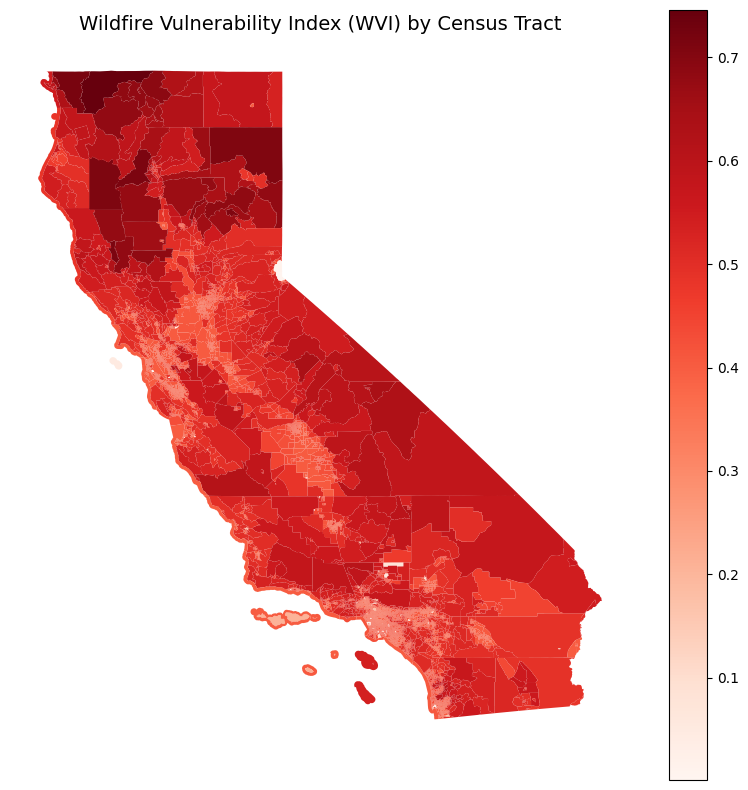

In [44]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

wvi_scaled.plot(
    column="WVI_score",
    cmap="Reds",
    linewidth=0,
    legend=True,
    ax=ax
)

ax.set_axis_off()
ax.set_title("Wildfire Vulnerability Index (WVI) by Census Tract", fontsize=14)
plt.show()

In [45]:
from sklearn.cluster import KMeans

X = wvi_scaled[["hazard_score", "vuln_score", "response_score"]].values
print(X.shape)

(9130, 3)


In [46]:
print("cluster" in wvi_scaled.columns)
print(wvi_scaled.columns.tolist())

False
['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'GEOIDFQ', 'NAME', 'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry', 'GEOID_clean', 'FIPS_clean', 'RPL_THEME1', 'RPL_THEME2', 'RPL_THEME3', 'RPL_THEME4', 'RPL_THEMES', 'fire_count', 'total_burned_area', 'max_burned_area', 'mean_burned_area', 'most_recent_fire_year', 'dist_to_station_m', 'hazard_score', 'vuln_score', 'response_score', 'WVI_score']


In [47]:
wvi_scaled[["hazard_score","vuln_score","response_score"]].isna().sum()

,0
hazard_score,0
vuln_score,0
response_score,0


In [49]:
from sklearn.cluster import KMeans

X = wvi_scaled[["hazard_score", "vuln_score", "response_score"]]

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

wvi_scaled["cluster"] = clusters

print(wvi_scaled["cluster"].value_counts().sort_index())
print("cluster in columns?", "cluster" in wvi_scaled.columns)

cluster
0     434
1    7400
2      67
3    1229
Name: count, dtype: int64
cluster in columns? True


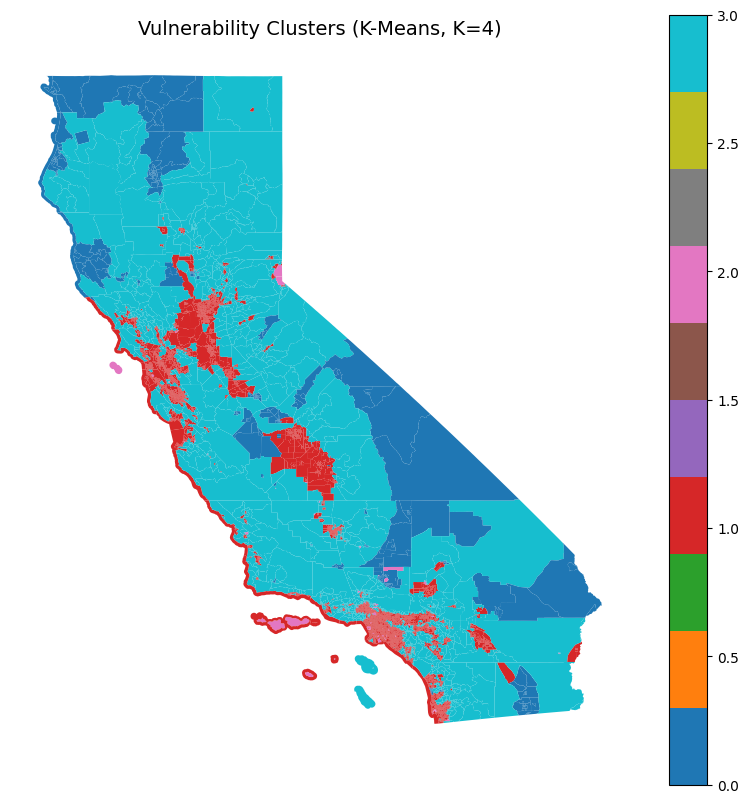

In [50]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

wvi_scaled.plot(
    column="cluster",
    cmap="tab10",
    linewidth=0,
    legend=True,
    ax=ax
)

ax.set_axis_off()
ax.set_title("Vulnerability Clusters (K-Means, K=4)", fontsize=14)
plt.show()

In [51]:
cluster_profile = (
    wvi_scaled.groupby("cluster")[["hazard_score","vuln_score","response_score","WVI_score"]]
    .mean()
    .sort_values("WVI_score", ascending=False)
)

cluster_profile

,hazard_score,vuln_score,response_score,WVI_score
cluster,,,,
3,0.247633,0.999477,0.111870,0.521218
0,0.052918,0.999666,0.418750,0.504784
1,0.000000,0.999559,0.079614,0.415747
2,0.038069,0.113413,0.123253,0.085243


In [52]:
feature_cols = [
    "fire_count",
    "total_burned_area",
    "max_burned_area",
    "mean_burned_area",
    "most_recent_fire_year",
    "RPL_THEME1",
    "RPL_THEME2",
    "RPL_THEME3",
    "RPL_THEME4",
    "dist_to_station_m",
]

target_col = "WVI_score"

X = wvi_scaled[feature_cols].values.astype("float32")
y = wvi_scaled[target_col].values.astype("float32")

X.shape, y.shape

((9130, 10), (9130,))

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape

((7304, 10), (1826, 10))

In [54]:
import tensorflow as tf
from tensorflow import keras

input_dim = X_train.shape[1]

model = keras.Sequential([
    keras.layers.Input(shape=(input_dim,)),

    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.2),

    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dropout(0.2),

    keras.layers.Dense(1, activation="linear")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",                         # Mean Squared Error
    metrics=[keras.metrics.MeanAbsoluteError(name="mae")]  # MAE
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_mae",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0262 - mae: 0.1281 - val_loss: 0.0030 - val_mae: 0.0529
Epoch 2/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0082 - mae: 0.0711 - val_loss: 0.0048 - val_mae: 0.0680
Epoch 3/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0060 - mae: 0.0608 - val_loss: 0.0042 - val_mae: 0.0643
Epoch 4/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0052 - mae: 0.0568 - val_loss: 0.0037 - val_mae: 0.0599
Epoch 5/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0040 - mae: 0.0497 - val_loss: 0.0025 - val_mae: 0.0486
Epoch 6/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0033 - mae: 0.0456 - val_loss: 0.0020 - val_mae: 0.0430
Epoch 7/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0031 - mae: 0.0425 - val_loss: 0.0023 - val_mae: 0.0469
Epoch 8/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0027 - mae: 0.0402 - val_loss: 0.0018 - val_mae: 0.0418
Epoch 9/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0

In [56]:
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test MSE : {test_loss:.4f}")
print(f"Test MAE : {test_mae:.4f}")

Test MSE : 0.0000
Test MAE : 0.0042


In [57]:
y_pred_all = model.predict(X).flatten()

wvi_scaled["WVI_pred"] = y_pred_all
wvi_scaled[["GEOID", "WVI_score", "WVI_pred"]].head()

286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,GEOID,WVI_score,WVI_pred
0,06001442700,0.402702,0.398347
1,06001442800,0.403994,0.399143
2,06037204920,0.403410,0.398687
3,06037205110,0.403019,0.398468
4,06037320101,0.407344,0.401566


58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


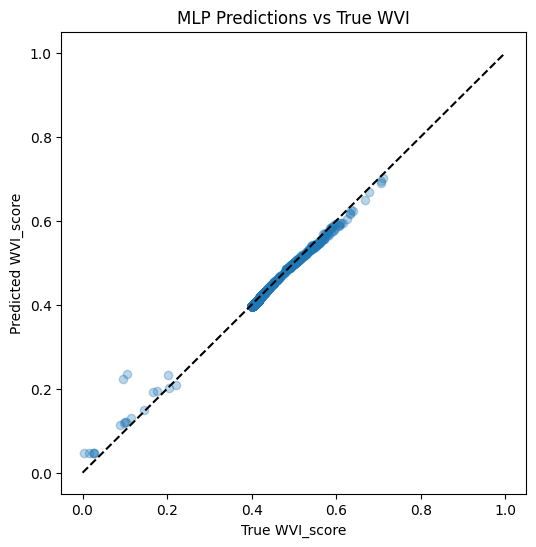

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, model.predict(X_test).flatten(), alpha=0.3)
plt.xlabel("True WVI_score")
plt.ylabel("Predicted WVI_score")
plt.title("MLP Predictions vs True WVI")
plt.plot([0,1], [0,1], "k--")  # y=x 기준선
plt.show()